# Practice and Experimentation

## Simple Linear Regression (OLS)

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### EDA

In [2]:
df = pd.read_csv('data/placement.csv')
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [ ]:
# statistics
df.describe()

,cgpa,package
count,200.000000,200.000000
mean,6.990500,2.996050
std,1.069409,0.691644
min,4.260000,1.370000
25%,6.190000,2.487500
50%,6.965000,2.995000
75%,7.737500,3.492500
max,9.580000,4.620000


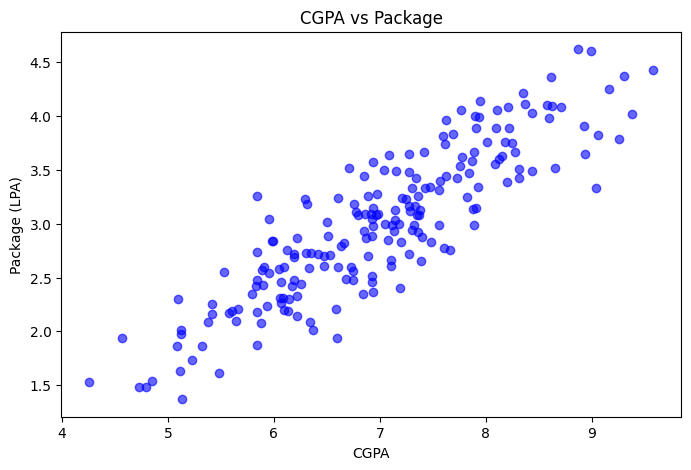

In [9]:
# 1. Scatter Plot - Relationship between CGPA and Package
plt.figure(figsize=(8, 5))
plt.scatter(df['cgpa'], df['package'], alpha=0.6, color='blue')
plt.xlabel('CGPA')
plt.ylabel('Package (LPA)')
plt.title('CGPA vs Package')
plt.show()

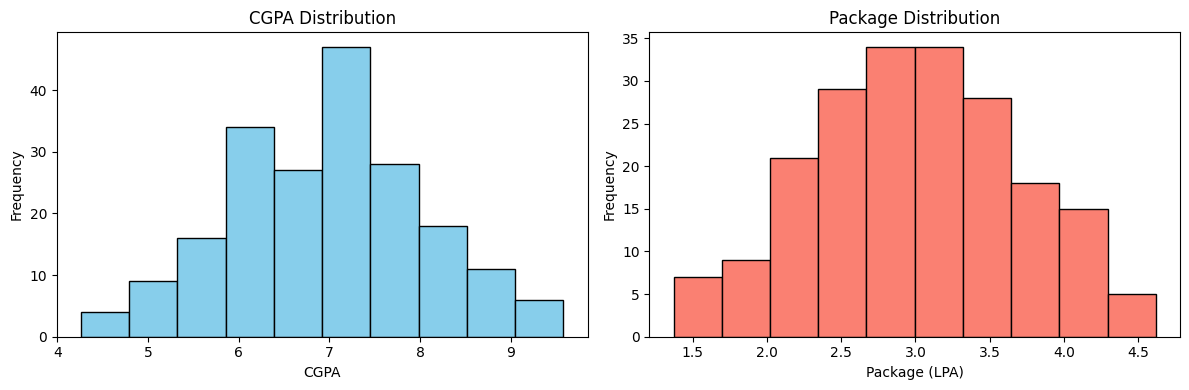

In [12]:
# 2. Histograms - Distribution of both variables
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['cgpa'], bins=10, color='skyblue', edgecolor='black')
axes[0].set_xlabel('CGPA')
axes[0].set_ylabel('Frequency')
axes[0].set_title('CGPA Distribution')

axes[1].hist(df['package'], bins=10, color='salmon', edgecolor='black')
axes[1].set_xlabel('Package (LPA)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Package Distribution')

plt.tight_layout()
plt.show()


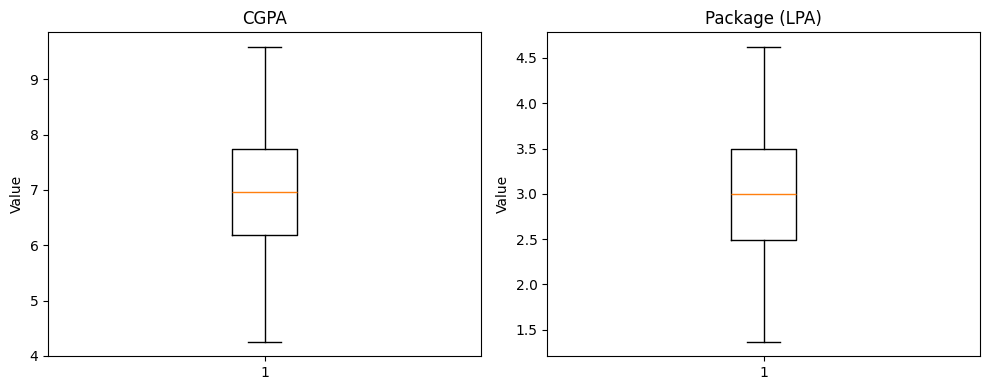

In [13]:
# 3. Box Plots - Outlier Detection
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].boxplot(df['cgpa'])
axes[0].set_title('CGPA')
axes[0].set_ylabel('Value')

axes[1].boxplot(df['package'])
axes[1].set_title('Package (LPA)')
axes[1].set_ylabel('Value')

plt.tight_layout()
plt.show()

In [14]:
# 4. Correlation
correlation = df['cgpa'].corr(df['package'])
print(f"Correlation between CGPA and Package: {correlation:.4f}")

Correlation between CGPA and Package: 0.8807


### Linear regression

In [15]:
class SimpleLinearRegression:

    def __init__(self):
        self.m = 0
        self.c = 0

    def fit(self, x, y):
        x_mean = np.mean(x)
        y_mean = np.mean(y)

        self.m = np.sum((x - x_mean) * (y - y_mean)) / np.sum((x - x_mean)**2)
        self.c = y_mean - self.m * x_mean

    def predict(self, x):
        return self.m * x + self.c

    def evaluate(self, y, y_pred, p=1):
        n = len(y)

        mae = np.mean(np.abs(y - y_pred))
        mse = np.mean((y - y_pred)**2)
        rmse = np.sqrt(mse)

        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)

        adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

        return mae, mse, rmse, r2, adj_r2


def train_test_split(x, y, test_size=0.2):
    n = len(x)
    indices = np.arange(n)

    np.random.shuffle(indices)

    split = int(n * (1 - test_size))

    train_idx = indices[:split]
    test_idx = indices[split:]

    return x[train_idx], x[test_idx], y[train_idx], y[test_idx]

In [16]:
# Extract data
x = df["cgpa"].values
y = df["package"].values

# Split data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

# Train model
model = SimpleLinearRegression()
model.fit(x_train, y_train)

# Predict on test data
y_pred = model.predict(x_test)

# Evaluate
metrics = model.evaluate(y_test, y_pred)

print("Slope (m):", model.m)
print("Intercept (c):", model.c)

print("\nEvaluation on Test Data:")
print("MAE:", metrics[0])
print("MSE:", metrics[1])
print("RMSE:", metrics[2])
print("R2:", metrics[3])
print("Adjusted R2:", metrics[4])

Slope (m): 0.5617187417317366
Intercept (c): -0.9661141517778109

Evaluation on Test Data:
MAE: 0.272988792627589
MSE: 0.11532010000901134
RMSE: 0.3395881329036858
R2: 0.7390203994600013
Adjusted R2: 0.7321525152352646


Slope (m): 0.5617187417317366
Intercept (c): -0.9661141517778109

Evaluation on Test Data:
MAE: 0.272988792627589
MSE: 0.11532010000901134
RMSE: 0.3395881329036858
R2: 0.7390203994600013
Adjusted R2: 0.7321525152352646


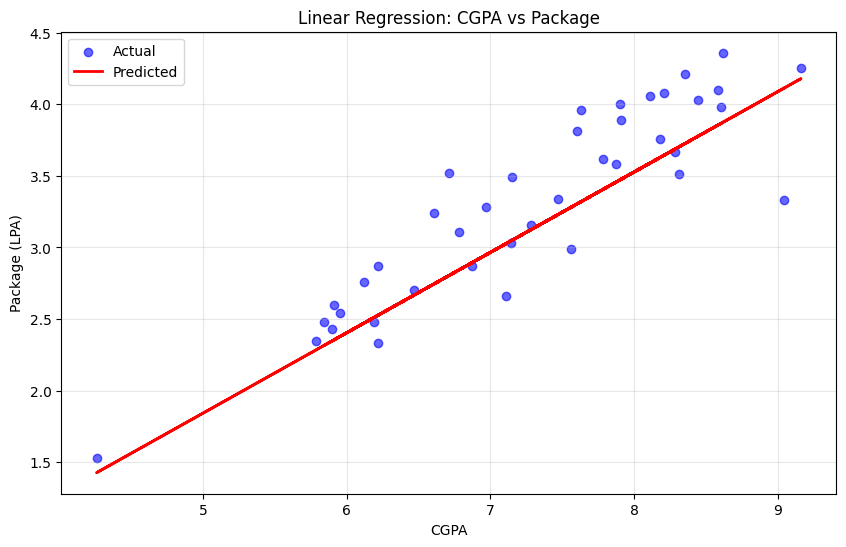

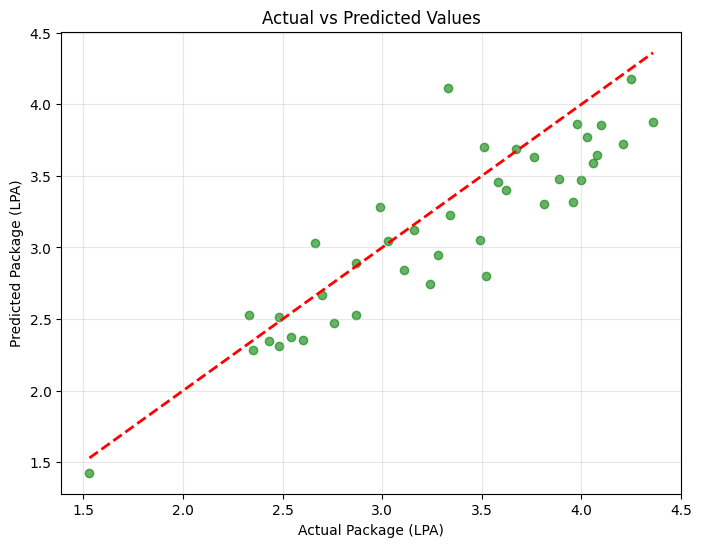

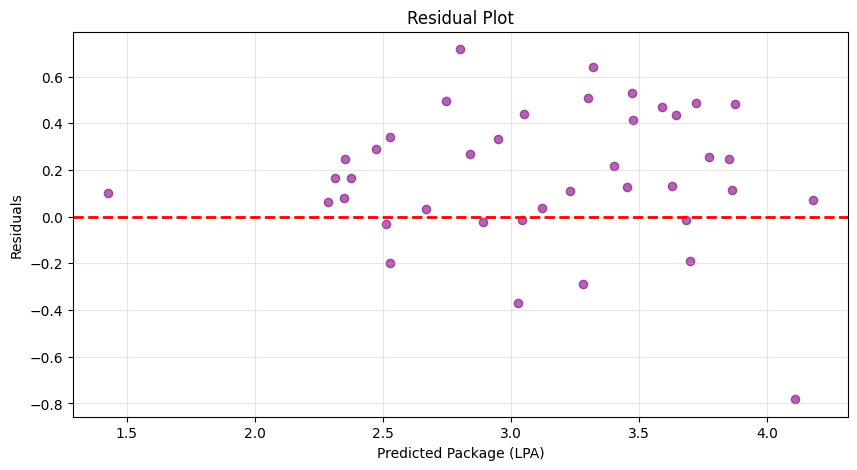

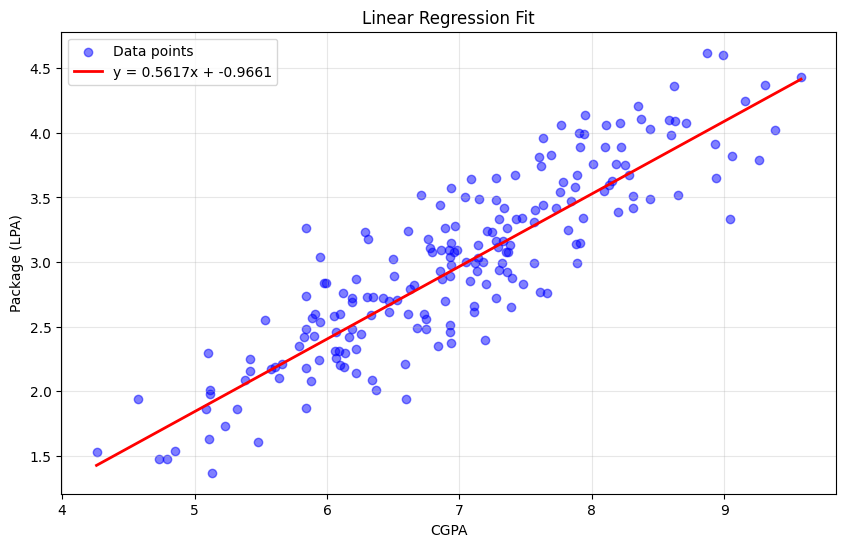

In [19]:
print("Slope (m):", model.m)
print("Intercept (c):", model.c)

print("\nEvaluation on Test Data:")
print("MAE:", metrics[0])
print("MSE:", metrics[1])
print("RMSE:", metrics[2])
print("R2:", metrics[3])
print("Adjusted R2:", metrics[4])

# Plot 1: Scatter plot with regression line
plt.figure(figsize=(10, 6))
plt.scatter(x_test, y_test, color='blue', alpha=0.6, label='Actual')
plt.plot(x_test, y_pred, color='red', linewidth=2, label='Predicted')
plt.xlabel('CGPA')
plt.ylabel('Package (LPA)')
plt.title('Linear Regression: CGPA vs Package')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Plot 2: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='green', alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.xlabel('Actual Package (LPA)')
plt.ylabel('Predicted Package (LPA)')
plt.title('Actual vs Predicted Values')
plt.grid(True, alpha=0.3)
plt.show()

# Plot 3: Residuals
residuals = y_test - y_pred
plt.figure(figsize=(10, 5))
plt.scatter(y_pred, residuals, color='purple', alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Package (LPA)')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True, alpha=0.3)
plt.show()

# Plot 4: Regression line on all data
x_line = np.array([x.min(), x.max()])
y_line = model.predict(x_line)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='blue', alpha=0.5, label='Data points')
plt.plot(x_line, y_line, color='red', linewidth=2, label=f'y = {model.m:.4f}x + {model.c:.4f}')
plt.xlabel('CGPA')
plt.ylabel('Package (LPA)')
plt.title('Linear Regression Fit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()